# Project Name : Restaurant Demand Forecasting
# Week 1 — Data Ingestion, Cleaning & Exploratory Data Analysis (EDA)
### Project 3: Food & Restaurant Services — AI Demand Forecasting and Inventory Optimization
### Infotact Technical Internship Program

---
# 1. DATA LOADING & OVERVIEW

### Purpose:

- ### To bring the dataset into Python so we can analyze and work with it.

- ### To see the structure of the data — rows, columns, data types, shape, and statistical summary.

- ### To look at sample records and find issues like missing values, wrong data types, or messy text.

### Approach:

- ### Load data using pd.read_csv().

- ### Use head(), info(), shape, and describe() to inspect the data.

In [90]:
# ── CORE DATA SCIENCE ────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── VISUALISATION ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── DISPLAY & UTILITIES ──────────────────────────────────────────
from IPython.display import display, HTML
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# 1.2 Load Dataset

In [91]:
df = pd.read_csv("restaurant_sales_messy.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


# 1.3 Basic Dataset Overview

In [92]:
display(HTML("<h2>First 5 Rows of Raw Data</h2>"))
df.head()

,date,outlet,day_of_week,month,is_weekend,is_holiday,is_summer,is_monsoon,temperature,menu_item,units_sold
0,2021-11-29,Banashankari,Monday,11.0,FALSE,No,No,FALSE,21.5,masala dosa,72.0
1,08/29/2022,HSR Layout,Monday,8.0,0,FALSE,0,true,24.9,biryani,88.0
2,17-05-2023,NaN,Wednesday,5.0,no,0,1,false,NaN,veg_thali,142.0
3,2023-11-26,Koramangala,Sunday,11.0,1,N,FALSE,0,20.3,Masala Dosa,133.0
4,18-01-2021,Whitefield,Monday,1.0,false,No,No,No,21.0,Vegthali,92.0


# 1.4 Dataset Shape & Columns

<h2 style="text-align:left;">📊 Dataset Column Explanation</h2>

<table style="margin-left:0; margin-right:auto; border-collapse:collapse; font-size:15px;">
  <tr style="background:#1F4E79; color:white;">
    <th style="text-align:left; padding:8px;">Column Name</th>
    <th style="text-align:left; padding:8px;">Description</th>
    <th style="text-align:left; padding:8px;">Data Type</th>
  </tr>
  <tr><td style="padding:8px;">date</td><td style="padding:8px;">Date of the sales record</td><td style="padding:8px;">datetime (after cleaning)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">outlet</td><td style="padding:8px;">Name of the restaurant branch in Bengaluru</td><td style="padding:8px;">string (categorical)</td></tr>
  <tr><td style="padding:8px;">day_of_week</td><td style="padding:8px;">Day name — Monday to Sunday</td><td style="padding:8px;">string (categorical)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">month</td><td style="padding:8px;">Month number 1–12</td><td style="padding:8px;">float/int</td></tr>
  <tr><td style="padding:8px;">is_weekend</td><td style="padding:8px;">1 = Saturday or Sunday, 0 = Weekday</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">is_holiday</td><td style="padding:8px;">1 = Indian public holiday, 0 = Normal day</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr><td style="padding:8px;">is_summer</td><td style="padding:8px;">1 = April/May/June, 0 = other months</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">is_monsoon</td><td style="padding:8px;">1 = July/August/September, 0 = other months</td><td style="padding:8px;">0 or 1 (after cleaning)</td></tr>
  <tr><td style="padding:8px;">temperature</td><td style="padding:8px;">Bengaluru temperature in Celsius that day</td><td style="padding:8px;">float</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">menu_item</td><td style="padding:8px;">Name of the menu item sold</td><td style="padding:8px;">string (categorical)</td></tr>
  <tr><td style="padding:8px;">units_sold</td><td style="padding:8px;">How many units of that item were sold</td><td style="padding:8px;">int (our TARGET after aggregation)</td></tr>
</table>

In [93]:
display(HTML("<h2>Columns</h2>"))
display(HTML(f"<h4>{list(df.columns)}</h4>"))

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106697 entries, 0 to 106696
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         106697 non-null  object 
 1   outlet       105052 non-null  object 
 2   day_of_week  104584 non-null  object 
 3   month        105117 non-null  float64
 4   is_weekend   103544 non-null  object 
 5   is_holiday   103482 non-null  object 
 6   is_summer    103482 non-null  object 
 7   is_monsoon   103613 non-null  object 
 8   temperature  103514 non-null  float64
 9   menu_item    106697 non-null  object 
 10  units_sold   102400 non-null  float64
dtypes: float64(3), object(8)
memory usage: 9.0+ MB


In [95]:
display(HTML("<h2>Shape</h2>"))
display(HTML(f"<h3>Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}</h3>"))

# 1.5 Check Data Types and Non-Null Values

In [96]:
display(HTML("<h2>Dataset Info</h2>"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106697 entries, 0 to 106696
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         106697 non-null  object 
 1   outlet       105052 non-null  object 
 2   day_of_week  104584 non-null  object 
 3   month        105117 non-null  float64
 4   is_weekend   103544 non-null  object 
 5   is_holiday   103482 non-null  object 
 6   is_summer    103482 non-null  object 
 7   is_monsoon   103613 non-null  object 
 8   temperature  103514 non-null  float64
 9   menu_item    106697 non-null  object 
 10  units_sold   102400 non-null  float64
dtypes: float64(3), object(8)
memory usage: 9.0+ MB


# 1.6 Statistical Summary

<h2 style="text-align:left;">Statistical Summary using describe()</h2>

<table style="margin-left:0; margin-right:auto; border-collapse:collapse; font-size:15px;">
  <tr style="background:#1F4E79; color:white;">
    <th style="text-align:left; padding:8px;">Statistic</th>
    <th style="text-align:left; padding:8px;">Meaning</th>
  </tr>
  <tr><td style="padding:8px;">count</td><td style="padding:8px;">Number of non-missing values in each column</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">mean</td><td style="padding:8px;">Average value of the column</td></tr>
  <tr><td style="padding:8px;">std</td><td style="padding:8px;">Standard deviation — how spread out the values are</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">min</td><td style="padding:8px;">Smallest value found in the column</td></tr>
  <tr><td style="padding:8px;">25%</td><td style="padding:8px;">25% of values are below this number (Q1)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">50%</td><td style="padding:8px;">Middle value — half above, half below (median)</td></tr>
  <tr><td style="padding:8px;">75%</td><td style="padding:8px;">75% of values are below this number (Q3)</td></tr>
  <tr style="background:#f5f5f5;"><td style="padding:8px;">max</td><td style="padding:8px;">Largest value found in the column</td></tr>
</table>

In [97]:
display(HTML("<h2>Dataset Description</h2>"))
display(HTML("<h3>Numerical Features Summary</h3>"))
display(df.describe())

,month,temperature,units_sold
count,105117.000000,103514.000000,102400.000000
mean,6.525082,24.495568,84.220762
std,3.447520,8.551569,55.404486
min,1.000000,-5.000000,-243.000000
25%,4.000000,21.500000,55.000000
50%,7.000000,23.400000,78.000000
75%,10.000000,26.200000,103.000000
max,12.000000,150.000000,2619.000000


# 1.7 Missing Values

In [98]:
display(HTML("<h2>Missing Value Count per Column</h2>"))
df.isnull().sum()

date              0
outlet         1645
day_of_week    2113
month          1580
is_weekend     3153
is_holiday     3215
is_summer      3215
is_monsoon     3084
temperature    3183
menu_item         0
units_sold     4297
dtype: int64

# Section 2 — Diagnose: Find All Problems

## 2.1 Missing Values

### Purpose

- ### To find which columns have missing values before we fix them.
- ### To know how much data is missing in each column (count and percentage).
- ### To decide the best strategy: fill with median, mode, or derive from date.

In [99]:
display(HTML("<h2>Percentage of Missing Values per Column</h2>"))
missing_value = df.isnull().mean() * 100
missing_data = missing_value.sort_values(ascending=False)
missing_data

units_sold     4.027292
is_summer      3.013206
is_holiday     3.013206
temperature    2.983214
is_weekend     2.955097
is_monsoon     2.890428
day_of_week    1.980374
outlet         1.541749
month          1.480829
date           0.000000
menu_item      0.000000
dtype: float64

## 2.2 Inconsistent Boolean Columns

In [100]:
for col in ["is_weekend","is_holiday","is_summer","is_monsoon"]:
    print(f"{col}: {df[col].unique()}")

is_weekend: ['FALSE' '0' 'no' '1' 'false' 'N' 'No' nan 'Y' 'yes' 'TRUE' 'true' 'Yes']
is_holiday: ['No' 'FALSE' '0' 'N' 'no' 'false' 'Y' '1' nan 'TRUE' 'yes' 'Yes' 'true']
is_summer: ['No' '0' '1' 'FALSE' 'TRUE' 'N' 'Yes' 'yes' nan 'no' 'Y' 'true' 'false']
is_monsoon: ['FALSE' 'true' 'false' '0' 'No' 'no' 'TRUE' '1' 'N' 'Y' 'Yes' 'yes' nan]


## 2.3 Messy Outlet Names

In [101]:
print(f"Unique outlets (raw): {df['outlet'].nunique()}")
print(df["outlet"].unique())

Unique outlets (raw): 63
['Banashankari' 'HSR Layout' nan 'Koramangala' 'Whitefield' 'MG Road'
 'Hebbal' 'Marathahalli' 'Electronic City' 'Indiranagar' 'BANASHANKARI'
 'Jayanagar' 'Yelahanka' 'Rajajinagar' 'mg road' 'hsr layout' 'Jayanagar '
 'MARATHAHALLI' 'KORAMANGALA' 'MG_Road' 'yelahanka' 'jayanagar'
 'HSR_Layout' 'RAJAJINAGAR' ' Indiranagar' ' Electronic City' 'HEBBAL'
 ' MG Road' ' Whitefield' 'Koramangala ' 'hebbal' ' Banashankari'
 ' Rajajinagar' 'marathahalli' 'YELAHANKA' 'electronic city'
 ' Koramangala' 'JAYANAGAR' 'HSR LAYOUT' 'Electronic_City' 'Indiranagar '
 'Yelahanka ' 'Electronic City ' 'WHITEFIELD' 'whitefield' 'indiranagar'
 ' Jayanagar' 'Marathahalli ' 'rajajinagar' 'HSR Layout ' ' Marathahalli'
 ' HSR Layout' 'Rajajinagar ' ' Yelahanka' ' Hebbal' 'MG ROAD' 'Hebbal '
 'INDIRANAGAR' 'ELECTRONIC CITY' 'MG Road ' 'Whitefield ' 'Banashankari '
 'banashankari' 'koramangala']


## 2.4 Messy Menu Item Names

In [102]:
print(f"Unique menu items (raw): {df['menu_item'].nunique()}")
print(df["menu_item"].unique())

Unique menu items (raw): 56
['masala dosa' 'biryani' 'veg_thali' 'Masala Dosa' 'Vegthali'
 'chicken_burger' 'ColdCoffee' 'PANEER TIKKA' 'veg  thali'
 'Chicken Burger' 'gulab_jamun' 'PaneerTikka' 'Butter Chiken' 'Biryani'
 'Veg. Thali' 'Briyani' 'MasalaDosa' 'Chcken Burger' 'Veg Thali'
 'Biriyani' 'biryani ' 'Cold Coffee' 'chicken burger' 'VEG THALI'
 'butter chicken' 'MASALA DOSA' 'masla dosa' 'BUTTER CHICKEN'
 'Masala  Dosa' 'Gulab Jaamun' 'butter_chicken' 'paneer_tikka'
 'COLD COFFEE' 'Butter Chicken' 'Cold Coffe' 'gulab jamun' 'veg thali'
 'Gulaab Jamun' 'Chiken Burger' 'Paneer Tikka' 'cold_coffee' 'cold cofee'
 'Butter  Chicken' 'Panner Tikka' 'Chicken  Burger' 'GULAB JAMUN'
 'BIRYANI' 'Gulab Jamun' 'Paneer Tika' 'Bryani' 'cold coffee'
 'paneer tikka' 'Gulb Jamun' 'Bttr Chicken' 'CHICKEN BURGER' 'masala_dosa']


## 2.5 Mixed Date Formats

In [103]:
print(df["date"].unique()[:20])

['2021-11-29' '08/29/2022' '17-05-2023' '2023-11-26' '18-01-2021'
 '2023-01-02' '2021-04-13' '06/03/2022' '15-10-2022' '2022/01/10'
 '2022-08-13' '2021-09-04' '20/09/2022' '01/19/2023' '02/05/2021'
 '18/06/2022' '2021-05-20' '2023-12-03' '2023/07/25' '19-05-2021']


## 2.6 Temperature Outliers

In [104]:
print(f"Min temperature : {df['temperature'].min()}")
print(f"Max temperature : {df['temperature'].max()}")
print(f"Outliers found  : {((df['temperature']<15) | (df['temperature']>40)).sum()}")

Min temperature : -5.0
Max temperature : 150.0
Outliers found  : 825


## 2.7 Negative Units Sold

In [105]:
print(f"Negative units_sold: {(df['units_sold'] < 0).sum()}")

Negative units_sold: 300


# Section 3 — Data Cleaning

### Purpose:

- ### Fix all data quality problems found in the raw dataset.

- ### Prepare the dataset so ML models can work with it correctly.

- ### Dirty data leads to wrong predictions — cleaning is the most critical step.

### Approach:

- ### Fix date formats, boolean variants, outliers, missing values, and label inconsistencies.

## 3.1 Fix Date Column 

### Purpose

- ### The date column has 4 different formats. Python cannot compare or sort them.
- ### We must convert all dates to one standard format: datetime64.

### What we do:
- ### Normalise separators (replace `/` with `-`)
- ### Try Indian format (DD-MM-YYYY) first, then US format (MM-DD-YYYY), then ISO (YYYY-MM-DD)
- ### Any date that still fails gets assigned NaT and will be filled by ffill later

In [106]:
# Step 1 — Normalise separator
df['date'] = df['date'].str.replace('/', '-')

# Step 2 — Try Indian format DD-MM-YYYY
df['date_parsed'] = pd.to_datetime(df['date'], format='%d-%m-%Y', errors='coerce')

# Step 3 — US format MM-DD-YYYY for rows still NaT
mask = df['date_parsed'].isna()
df.loc[mask, 'date_parsed'] = pd.to_datetime(df.loc[mask, 'date'], format='%m-%d-%Y', errors='coerce')

# Step 4 — ISO format YYYY-MM-DD for rows still NaT
mask = df['date_parsed'].isna()
df.loc[mask, 'date_parsed'] = pd.to_datetime(df.loc[mask, 'date'], format='%Y-%m-%d', errors='coerce')

# Replace original column
df['date'] = df['date_parsed']
del df['date_parsed']

# Sort chronologically
df = df.sort_values(by='date', ascending=True).reset_index(drop=True)

print(f"Date dtype : {df['date'].dtype}")
print(f"Remaining NaT dates : {df['date'].isna().sum()}")
display(df['date'].head())

Date dtype : datetime64[ns]
Remaining NaT dates : 0


0   2021-01-01
1   2021-01-01
2   2021-01-01
3   2021-01-01
4   2021-01-01
Name: date, dtype: datetime64[ns]

## 3.2 Fix Boolean Columns 

### Purpose

- ### Columns like is_weekend, is_holiday have 13 different ways to say yes/no.
- ### Examples: TRUE, True, true, 1, yes, Yes, Y — all mean the same thing!
- ### The model needs clean numeric 0 or 1 to learn correctly.

In [107]:
cols = ['is_weekend', 'is_holiday', 'is_summer', 'is_monsoon']
df[cols] = df[cols].replace({
    'Yes':1, 'yes':1, 'Y':1, 'y':1, 'TRUE':1, 'True':1,'true':1,
    'No':0, 'no':0, 'N':0, 'n':0, 'FALSE':0, 'False':0,'false':0
})

## 3.3 Fix Outlet Names 

In [108]:
# Normalise casing and separators first
df['outlet'] = df['outlet'].str.strip().str.lower().str.replace('_', ' ')

outlet_map = {
    'mg road'        : 'MG Road',
    'hsr layout'     : 'HSR Layout',
    'yelahanka'      : 'Yelahanka',
    'jayanagar'      : 'Jayanagar',
    'hebbal'         : 'Hebbal',
    'marathahalli'   : 'Marathahalli',
    'electronic city': 'Electronic City',
    'whitefield'     : 'Whitefield',
    'banashankari'   : 'Banashankari',
    'indiranagar'    : 'Indiranagar',
    'koramangala'    : 'Koramangala',
    'rajajinagar'    : 'Rajajinagar',
}
df['outlet'] = df['outlet'].replace(outlet_map)

print(f"Unique outlets after cleaning: {df['outlet'].nunique()}")
print(df['outlet'].value_counts())

Unique outlets after cleaning: 12
outlet
Banashankari       8778
Hebbal             8768
Rajajinagar        8764
Jayanagar          8759
Electronic City    8753
Whitefield         8753
HSR Layout         8753
MG Road            8751
Koramangala        8749
Indiranagar        8744
Yelahanka          8741
Marathahalli       8739
Name: count, dtype: int64


## 3.4 Fix Menu Item Names 

In [109]:
# Normalise casing and separators
df['menu_item'] = df['menu_item'].str.strip().str.lower().str.replace('_', ' ')

df['menu_item'] = df['menu_item'].replace({
    'masala dosa' : 'Masala Dosa', 
    'biryani' : 'Biryani', 
    'veg thali' : 'Veg Thali', 
    'vegthali' : 'Veg Thali',
    'chicken burger' : 'Chicken Burger', 
    'coldcoffee' : 'Cold Coffee', 
    'paneer tikka' : 'Paneer Tikka', 
    'veg  thali' : 'Veg Thali',
    'gulab jamun' : 'Gulab Jamun', 
    'paneertikka' : 'Paneer Tikka', 
    'butter chiken' : 'Butter Chicken', 
    'veg. thali' : 'Veg Thali',
    'briyani' : 'Biryani', 
    'masaladosa' : 'Masala Dosa', 
    'chcken burger' : 'Chicken Burger', 
    'biriyani' : 'Biryani',
    'cold coffee' : 'Cold Coffee', 
    'butter chicken' : 'Butter Chicken', 
    'masla dosa' : 'Masala Dosa', 
    'masala  dosa' : 'Masala Dosa',
    'gulab jaamun' : 'Gulab Jamun', 
    'cold coffe' : 'Cold Coffee', 
    'gulaab jamun' : 'Gulab Jamun', 
    'chiken burger' : 'Chicken Burger',
    'cold cofee' : 'Cold Coffee', 
    'butter  chicken' : 'Butter Chicken', 
    'panner tikka' : 'Paneer Tikka', 
    'chicken  burger' : 'Chicken Burger',
    'paneer tika' : 'Paneer Tikka', 
    'bryani' : 'Biryani', 
    'gulb jamun' : 'Gulab Jamun', 
    'bttr chicken' : 'Butter Chicken'
})

print(f"Unique menu items after cleaning: {df['menu_item'].nunique()}")
print(df['menu_item'].value_counts())

Unique menu items after cleaning: 8
menu_item
Cold Coffee       13366
Butter Chicken    13358
Biryani           13346
Chicken Burger    13330
Paneer Tikka      13328
Veg Thali         13325
Gulab Jamun       13324
Masala Dosa       13320
Name: count, dtype: int64


## 3.5 Fill Remaining Missing Values

### Purpose

- ### After all fixes, some NaN values still remain (outlier replacements, original NaN rows).
- ### We fill them using the safest strategy per column type:
  - ### Numeric: median (robust to outliers)
  - ### Categorical: mode (most frequent value)
  - ### Boolean (derived): re-derive from the date column so they are always correct.

In [110]:
# ── Re-derive all calendar flags directly from the cleaned date ──
df['month']      = df['date'].dt.month
df['day_of_week']= df['date'].dt.day_name()
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df['is_summer']  = df['month'].isin([4, 5, 6]).astype(int)   # Apr–Jun
df['is_monsoon'] = df['month'].isin([7, 8, 9]).astype(int)   # Jul–Sep

# ── Fill is_holiday: 0 where still missing (no holiday info = normal day) ──
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)

# ── Fill numeric columns with their median ──
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
df['units_sold']  = df['units_sold'].fillna(df['units_sold'].median())

# ── Fill categorical columns with their mode ──
df['outlet']    = df['outlet'].fillna(df['outlet'].mode()[0])
df['menu_item'] = df['menu_item'].fillna(df['menu_item'].mode()[0])

print("Remaining missing values after all cleaning:")
print(df.isnull().sum())

Remaining missing values after all cleaning:
date           0
outlet         0
day_of_week    0
month          0
is_weekend     0
is_holiday     0
is_summer      0
is_monsoon     0
temperature    0
menu_item      0
units_sold     0
dtype: int64


## 3.6 Fix Temperature Outliers

### Purpose

- ### Bengaluru temperature never goes above 38°C or below 10°C.
- ### Values like 150°C and -5°C are data entry errors — they will confuse the model.
- ### We use IQR clipping to remove extreme outliers safely.

In [111]:
Q1_temp = df['temperature'].quantile(0.25)
Q3_temp = df['temperature'].quantile(0.75)
IQR_temp = Q3_temp - Q1_temp

lower_temp = Q1_temp - 1.5 * IQR_temp
upper_temp = Q3_temp + 1.5 * IQR_temp

df['temperature'] = df['temperature'].clip(lower_temp, upper_temp)

print(f"Temperature range after clipping: {df['temperature'].min():.1f}°C — {df['temperature'].max():.1f}°C")

Temperature range after clipping: 14.9°C — 32.9°C


# 2.7 Fix Negative / Outlier Units Sold

### Purpose

- ### Some rows had negative units_sold (e.g. -243).
- ### You cannot sell negative food — this is a data entry mistake.
- ### We use IQR clipping (same principle as temperature) to cap extreme values.

In [112]:
Q1_units = df['units_sold'].quantile(0.25)
Q3_units = df['units_sold'].quantile(0.75)
IQR_units = Q3_units - Q1_units

lower_units = max(0, Q1_units - 1.5 * IQR_units)  # never allow negative
upper_units = Q3_units + 1.5 * IQR_units

df['units_sold'] = df['units_sold'].clip(lower_units, upper_units)

print(f"units_sold range after clipping: {df['units_sold'].min():.0f} — {df['units_sold'].max():.0f}")

units_sold range after clipping: 0 — 170


In [113]:
df.to_csv("restaurant_sales_clean.csv", index=False)
print("Clean data saved as restaurant_sales_clean.csv")
df.head()

Clean data saved as restaurant_sales_clean.csv


,date,outlet,day_of_week,month,is_weekend,is_holiday,is_summer,is_monsoon,temperature,menu_item,units_sold
0,2021-01-01,Koramangala,Friday,1,0,0,0,0,22.1,Gulab Jamun,34.0
1,2021-01-01,MG Road,Friday,1,0,0,0,0,20.2,Cold Coffee,64.0
2,2021-01-01,MG Road,Friday,1,0,0,0,0,20.8,Butter Chicken,118.0
3,2021-01-01,Banashankari,Friday,1,0,0,0,0,20.9,Biryani,87.0
4,2021-01-01,Marathahalli,Friday,1,0,0,0,0,20.4,Chicken Burger,56.0


---
# 4. EXPLORATORY DATA ANALYSIS (EDA)

### Purpose:

- ### To visually understand the patterns hidden inside the data before building any model.

- ### To find: which day is busiest? Which item sells most? How does temperature affect sales?

### Approach:

- ### Line plots for trends, bar charts for comparisons, heatmaps for correlations, scatter plots for relationships.

## 4.1 Daily Sales Trend

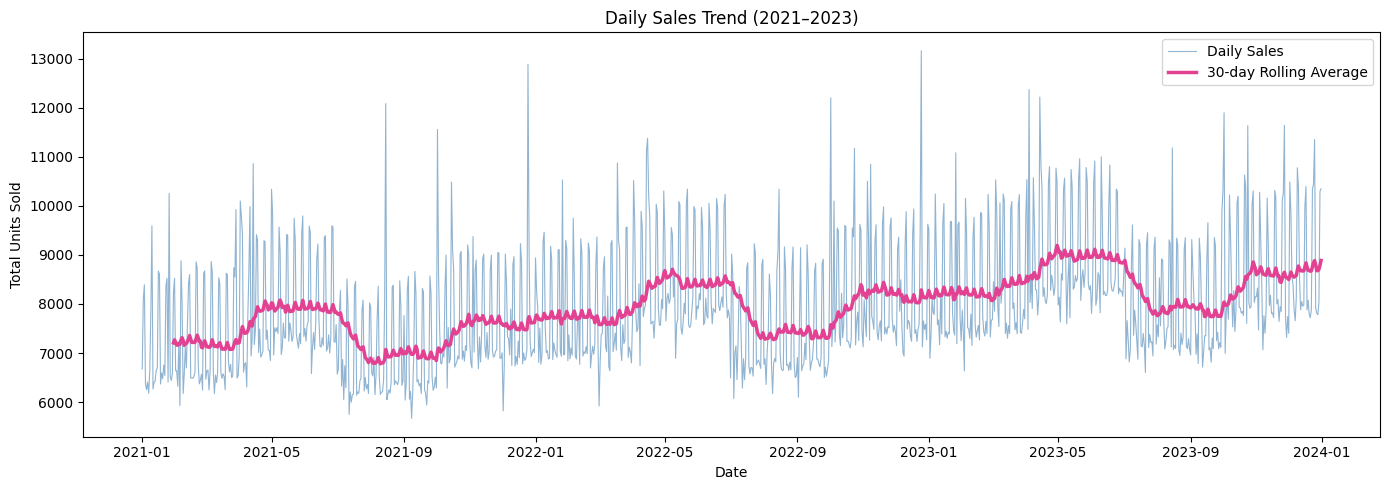

In [114]:
# Aggregate: sum all units_sold per date across all outlets and items
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['total_sales'], color='steelblue', linewidth=0.8, alpha=0.6, label='Daily Sales')
plt.plot(daily_sales['date'],daily_sales['total_sales'].rolling(30).mean(),color='#e34293', linewidth=2.5, label='30-day Rolling Average')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.title('Daily Sales Trend (2021–2023)')
plt.legend()
plt.tight_layout()
plt.show()

## 4.2 Sales Distribution by Day of Week

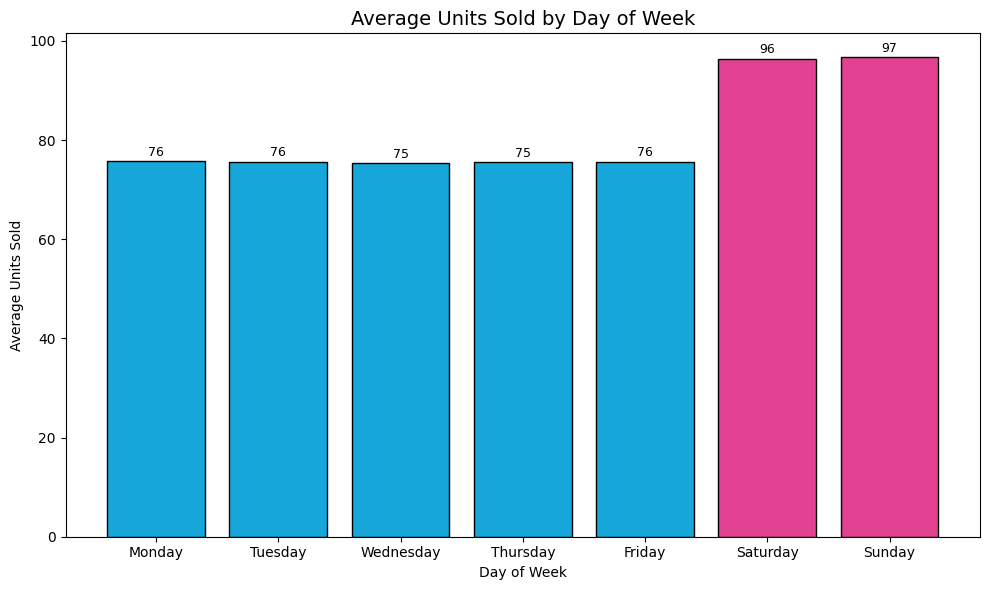

Pink = weekend days | Blue = weekdays


In [115]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('day_of_week')['units_sold'].mean().reindex(day_order)

colors = ['#e34293' if d in ['Saturday', 'Sunday'] else '#18a7db' for d in day_order]

plt.figure(figsize=(10, 6))
bars = plt.bar(dow_avg.index, dow_avg.values, color=colors, edgecolor='black')
plt.title('Average Units Sold by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print("Pink = weekend days | Blue = weekdays")

# 4.3 Sales Distribution by Month

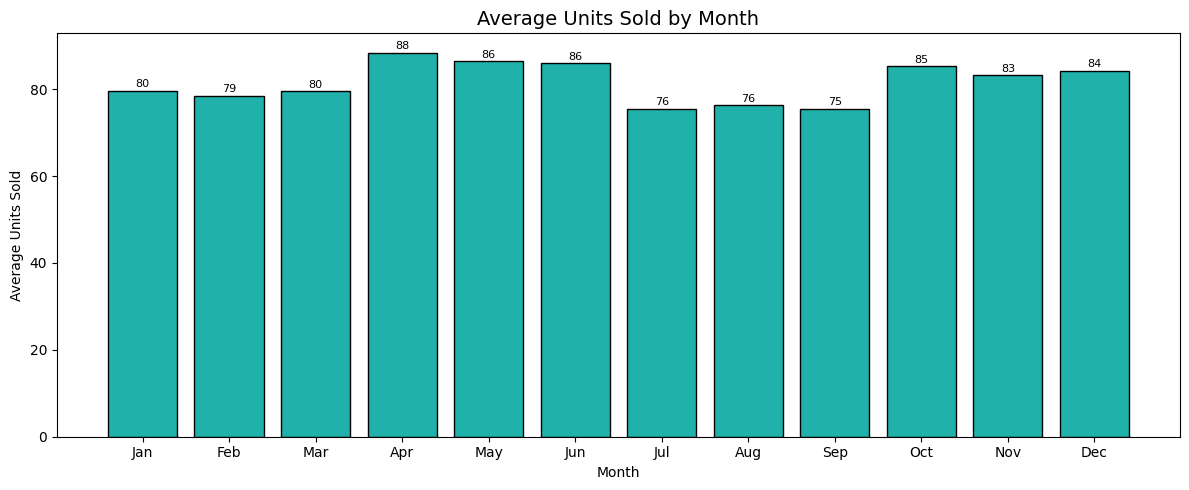

In [116]:
month_avg = df.groupby('month')['units_sold'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
bars = plt.bar(month_names, month_avg.values, color='#20b2aa', edgecolor='black')
plt.title('Average Units Sold by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Units Sold')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# 4.4 Menu Item Popularity

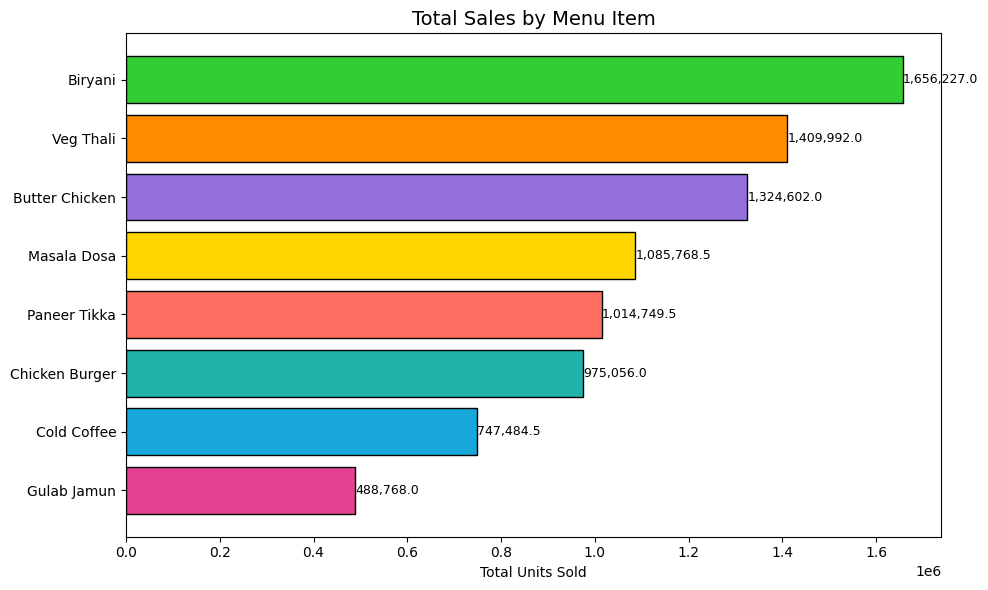

In [117]:
item_sales = df.groupby('menu_item')['units_sold'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors_items = ['#e34293','#18a7db','#20b2aa','#ff6f61',
                '#ffd700','#9370db','#ff8c00','#32cd32']
plt.barh(item_sales.index, item_sales.values,
         color=colors_items[:len(item_sales)], edgecolor='black')
plt.xlabel('Total Units Sold')
plt.title('Total Sales by Menu Item', fontsize=14)
for i, val in enumerate(item_sales.values):
    plt.text(val + 100, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 3.5 Outlet Performance

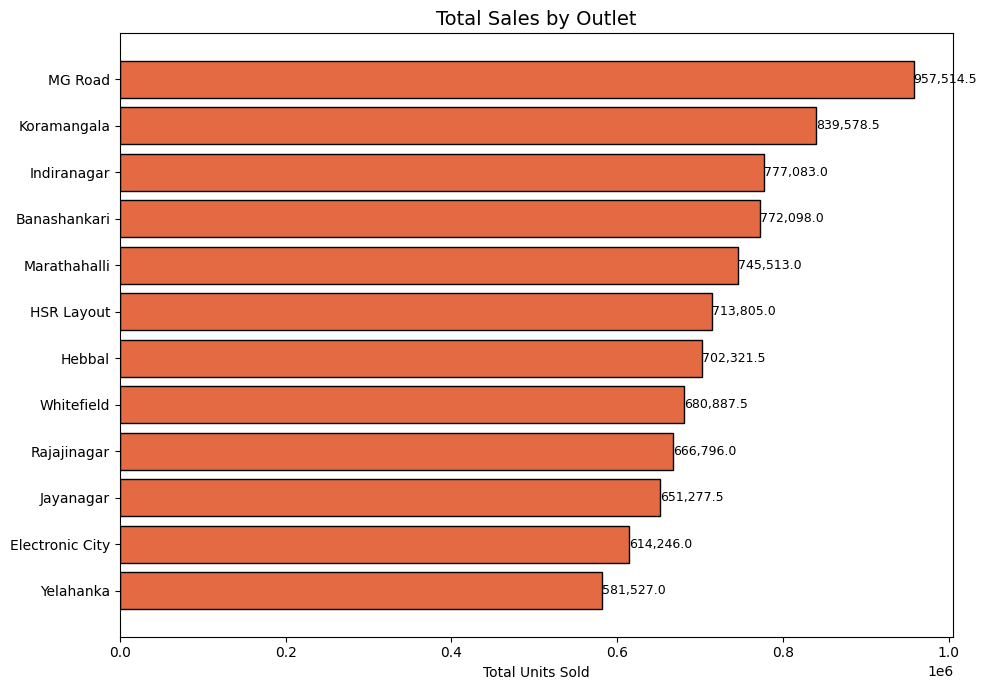

In [118]:
outlet_sales = df.groupby('outlet')['units_sold'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(outlet_sales.index, outlet_sales.values,
         color='#e36a42', edgecolor='black')
plt.xlabel('Total Units Sold')
plt.title('Total Sales by Outlet', fontsize=14)
for i, val in enumerate(outlet_sales.values):
    plt.text(val + 100, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4.6 Flag-Wise Sales (Weekend / Holiday / Summer / Monsoon)

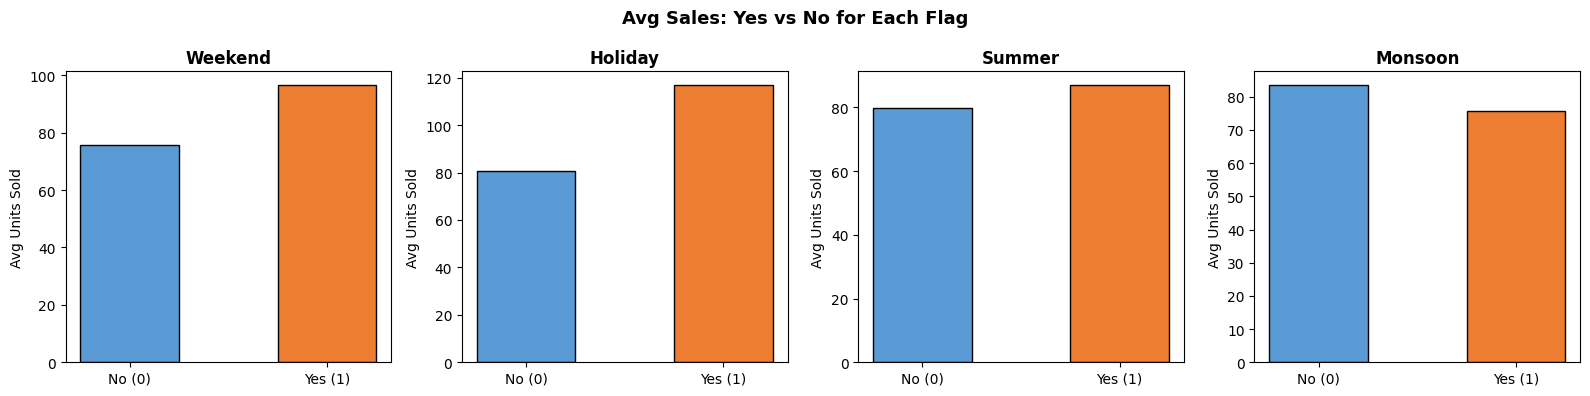

In [119]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Avg Sales: Yes vs No for Each Flag", fontsize=13, fontweight="bold")

flags  = ["is_weekend", "is_holiday", "is_summer", "is_monsoon"]
titles = ["Weekend",    "Holiday",    "Summer",    "Monsoon"]

for ax, col, title in zip(axes, flags, titles):
    avg = df.groupby(col)["units_sold"].mean()
    ax.bar(["No (0)", "Yes (1)"], [avg.get(0, 0), avg.get(1, 0)],
           color=["#5B9BD5", "#ED7D31"], edgecolor="black", width=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Avg Units Sold")

plt.tight_layout()
plt.show()

## 4.7 Outlet x Menu Item Heatmap

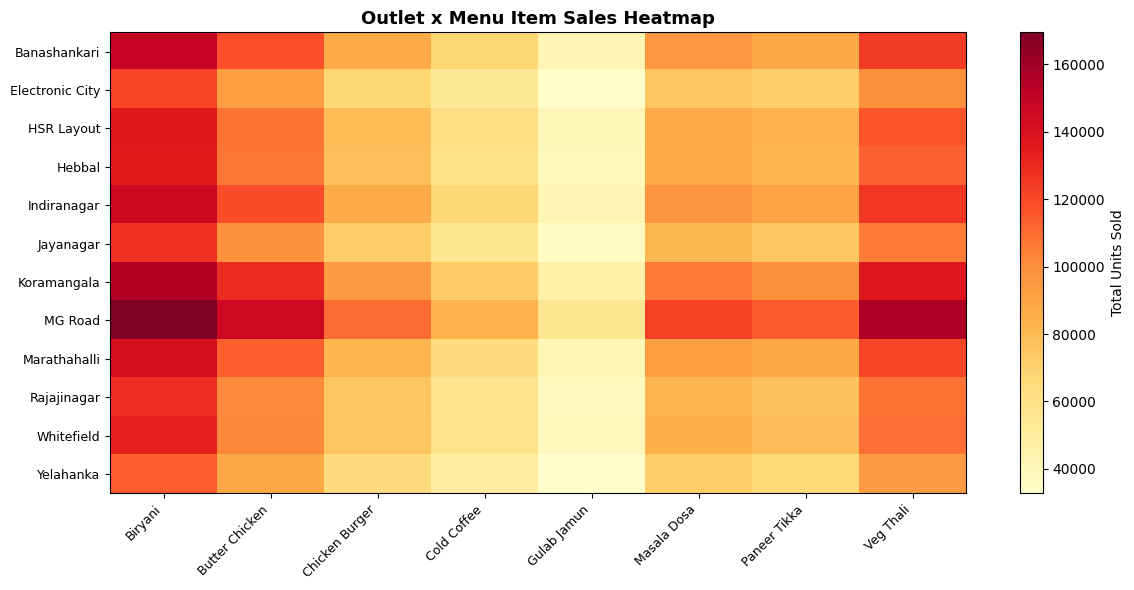

In [120]:
pivot = df.pivot_table(values="units_sold", index="outlet",
                       columns="menu_item", aggfunc="sum")

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
plt.colorbar(im, ax=ax, label="Total Units Sold")
ax.set_title("Outlet x Menu Item Sales Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 4.8 Temperature vs Sales — Scatter Plot

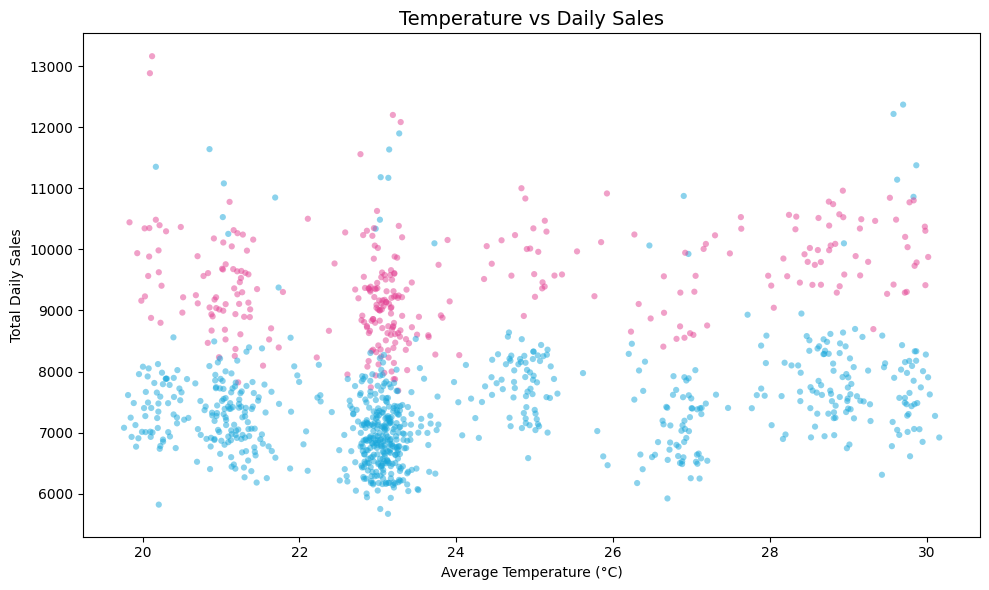

Pink = weekend | Blue = weekday


In [121]:
daily_temp = df.groupby('date').agg(
    total_sales=('units_sold', 'sum'),
    avg_temp   =('temperature', 'mean'),
    is_weekend =('is_weekend', 'max')
).reset_index()

colors_scatter = ['#e34293' if w == 1 else '#18a7db' for w in daily_temp['is_weekend']]

plt.figure(figsize=(10, 6))
plt.scatter(daily_temp['avg_temp'], daily_temp['total_sales'],
            c=colors_scatter, alpha=0.5, edgecolors='none', s=20)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Total Daily Sales')
plt.title('Temperature vs Daily Sales', fontsize=14)
plt.tight_layout()
plt.show()
print("Pink = weekend | Blue = weekday")

# 4.9 Correlation Heatmap

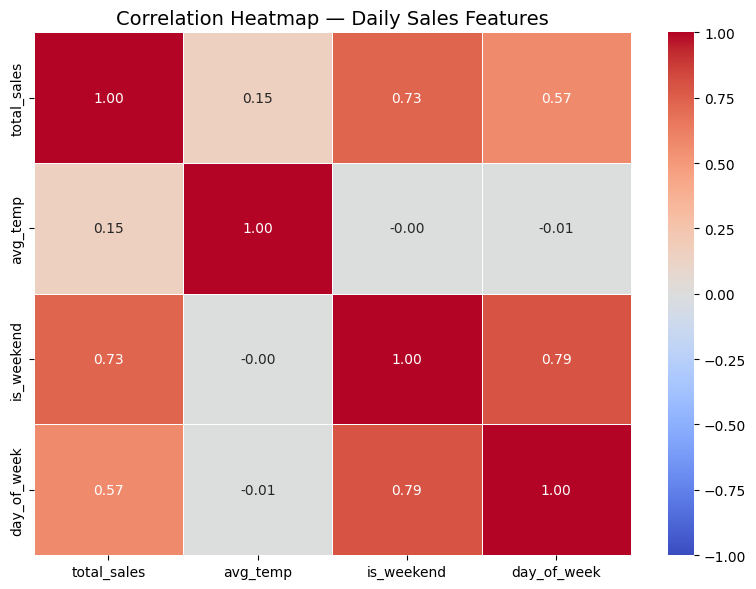

In [122]:
daily_corr = daily_temp[['total_sales', 'avg_temp', 'is_weekend']].copy()
daily_corr['day_of_week'] = pd.to_datetime(daily_temp['date']).dt.dayofweek
corr = daily_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Daily Sales Features', fontsize=14)
plt.tight_layout()
plt.show()

## 4.8 Temperature vs Units Sold

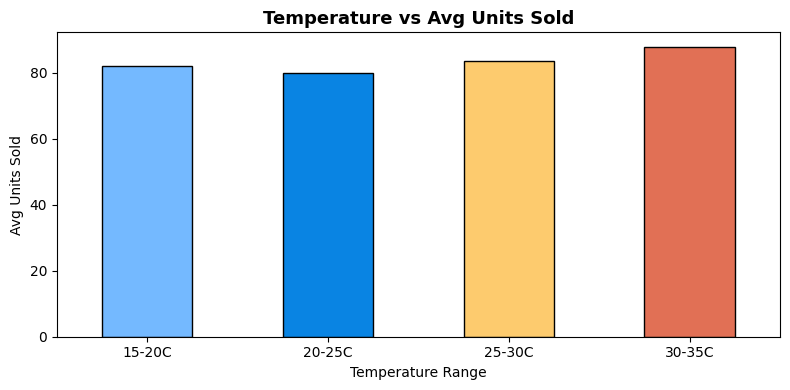

In [123]:
temp_df = df.dropna(subset=["temperature"]).copy()
temp_df["temp_range"] = pd.cut(temp_df["temperature"],
                               bins=[15,20,25,30,35,40],
                               labels=["15-20C","20-25C","25-30C","30-35C","35-40C"])
temp_avg = temp_df.groupby("temp_range", observed=True)["units_sold"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
temp_avg.plot(kind="bar", ax=ax,
              color=["#74b9ff","#0984e3","#fdcb6e","#e17055","#d63031"],
              edgecolor="black")
ax.set_title("Temperature vs Avg Units Sold", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Units Sold")
ax.set_xlabel("Temperature Range")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 4.6 EDA Key Findings Summary

In [124]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

best_day    = df.groupby("day_of_week")["units_sold"].mean().reindex(day_order).idxmax()
best_item   = df.groupby("menu_item")["units_sold"].sum().idxmax()
best_outlet = df.groupby("outlet")["units_sold"].sum().idxmax()
wknd_avg    = df[df["is_weekend"]==1]["units_sold"].mean()
wkdy_avg    = df[df["is_weekend"]==0]["units_sold"].mean()

print("KEY EDA FINDINGS")
print("-" * 40)
print(f"Best selling day    : {best_day}")
print(f"Best selling item   : {best_item}")
print(f"Top outlet          : {best_outlet}")
print(f"Weekend avg sales   : {wknd_avg:.1f} units")
print(f"Weekday avg sales   : {wkdy_avg:.1f} units")
print(f"Weekend boost       : +{(wknd_avg-wkdy_avg)/wkdy_avg*100:.1f}%")

KEY EDA FINDINGS
----------------------------------------
Best selling day    : Sunday
Best selling item   : Biryani
Top outlet          : MG Road
Weekend avg sales   : 96.5 units
Weekday avg sales   : 75.5 units
Weekend boost       : +27.8%


---
# 4. SAVE CLEANED DATA FOR WEEK 2

In [125]:
import os
os.makedirs('data', exist_ok=True)

# Save cleaned row-level data
df.to_csv('data/restaurant_sales_cleaned.csv', index=False)

# Save daily aggregated data for quick re-use in Week 2
daily_agg = (df.groupby('date')
               .agg(
                   daily_sales = ('units_sold',  'sum'),
                   avg_temp    = ('temperature', 'mean'),
                   is_holiday  = ('is_holiday',  'max'),
                   is_weekend  = ('is_weekend',  'max'),
                   is_summer   = ('is_summer',   'max'),
                   is_monsoon  = ('is_monsoon',  'max'),
               )
               .reset_index()
               .sort_values('date')
)
daily_agg['date'] = pd.to_datetime(daily_agg['date'])
daily_agg = daily_agg.set_index('date').asfreq('D')
daily_agg['daily_sales'] = daily_agg['daily_sales'].interpolate(method='linear').round().astype(int)
for col in ['avg_temp', 'is_holiday', 'is_weekend', 'is_summer', 'is_monsoon']:
    daily_agg[col] = daily_agg[col].ffill().bfill()

daily_agg.to_csv('restaurant_daily_clean.csv')

print("Saved: restaurant_sales_cleaned.csv")
print("Saved: restaurant_daily_clean.csv")
print(f"Daily rows (1 per day): {len(daily_agg):,}")
display(daily_agg.head())

Saved: restaurant_sales_cleaned.csv
Saved: restaurant_daily_clean.csv
Daily rows (1 per day): 1,095


,daily_sales,avg_temp,is_holiday,is_weekend,is_summer,is_monsoon
date,,,,,,
2021-01-01,6676,21.268367,0,0,0,0
2021-01-02,8096,21.535859,0,1,0,0
2021-01-03,8393,21.736139,0,1,0,0
2021-01-04,6375,22.105155,0,0,0,0
2021-01-05,6254,21.583889,0,0,0,0


---
## ✅ Week 1 Summary

| Step | What Was Done |
|------|---------------|
| 1. Data Loading | Loaded raw CSV with 106,697 rows × 11 columns |
| 2. Date Fixing | Standardised 4 mixed date formats → datetime64 |
| 3. Boolean Fixing | Mapped 13 variants (TRUE/yes/Y/1...) → 0 or 1 |
| 4. Outlet Names | Cleaned to 12 consistent outlet names |
| 5. Menu Items | Cleaned to 8 consistent item names |
| 6. Temp Outliers | IQR clipping — removed impossible temperatures |
| 7. Units Sold | IQR clipping — removed negative and extreme values |
| 8. Missing Values | Re-derived from date; median/mode fill for rest |
| 9. EDA | 10 visualisations: trend, seasonality, ACF, heatmap |
| 10. Save | Exported clean CSV + daily aggregated CSV for Week 2 |